<a href="https://colab.research.google.com/github/it25102877/IT2011-AIML-Project/blob/member-2-IT25102550/IT25102550.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IT2011 - Artificial Intelligence and Machine Learning**
 Student ID: IT25102550

Model: Logistic Regression with Hyperparameter Tuning & Cross-Validation

Environment: Google Colab

**Step 1: Install and Import Libraries**

In [1]:

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

# Download NLTK resources safely
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Step 1 Complete: All required libraries imported successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Step 1 Complete: All required libraries imported successfully!


**Step 2: Text Preprocessing Pipeline**

In [2]:
lemmatizer = WordNetLemmatizer()
standard_stopwords = set(stopwords.words('english'))
domain_stopwords = {'movie', 'film', 'watch', 'watching', 'actor', 'actress', 'scene', 'character', 'one', 'make', 'show', 'see'}
all_stopwords = standard_stopwords.union(domain_stopwords)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    tokens = word_tokenize(text.lower())
    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token.isalnum() and token not in all_stopwords
    ]
    return " ".join(cleaned_tokens)

print("Step 2 Complete: Preprocessing function initialized.")

Step 2 Complete: Preprocessing function initialized.


**Step 3: Load Dataset**

In [6]:
file_path = "Movies_Reviews_modified_version12.csv"

if not os.path.exists(file_path):
    print(f"'{file_path}' not found in environment. Generating synthetic dataset to run the pipeline...")

    # Generate a dummy movie review dataset with multi-class emotions
    synthetic_data = {
        'Reviews': [
            "This movie was absolutely amazing! I loved every single moment of it.",
            "I felt so sad watching this heartbreaking story, beautiful but depressing.",
            "What a waste of time. I am so angry that I paid money to watch this garbage.",
            "Wow, what an incredible plot twist! I did not expect that ending at all!",
            "An outstanding performance by the main cast, simply spectacular!",
            "The tragic ending left me crying in tears. Highly emotional film.",
            "Extremely frustrated with the terrible writing and plot holes. Do not watch!",
            "Shocking revelations! The mystery kept me on the edge of my seat!",
            "A truly wonderful and delightful comedy that brings sheer happiness.",
            "The loss of the main character was deeply saddening and painful to watch.",
            "I hate this director. This film is an absolute insult to the audience.",
            "Unbelievable visuals! I was completely surprised by how great this looked!"
        ],
        'emotion': [
            'happy', 'sad', 'angry', 'surprise',
            'happy', 'sad', 'angry', 'surprise',
            'happy', 'sad', 'angry', 'surprise'
        ]
    }
    df = pd.DataFrame(synthetic_data)
else:
    print(f"Found '{file_path}'. Loading dataset...")
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

# Drop rows with missing text or target labels
df = df.dropna(subset=['Reviews', 'emotion'])
print(f"Dataset loaded. Total Samples: {len(df)}")

# Preprocess text column
print("Applying text preprocessing...")
df['cleaned_review'] = df['Reviews'].astype(str).apply(preprocess_text)

X = df['cleaned_review']
y = df['emotion']

'Movies_Reviews_modified_version12.csv' not found in environment. Generating synthetic dataset to run the pipeline...
Dataset loaded. Total Samples: 12
Applying text preprocessing...


**Step 4: Train-Test Split (Preventing Data Leakage)**

In [8]:
if 'X' not in locals() or 'y' not in locals():
    raise NameError("Variables 'X' and 'y' are not defined. Please make sure 'Movies_Reviews_modified_version12.csv' is uploaded and Step 3 runs successfully.")
else:
    num_classes = len(np.unique(y))
    test_size_samples = int(len(X) * 0.20)

    # Fallback if dataset is too small to perform stratified split
    if test_size_samples < num_classes:
        print(f"Warning: Dataset is too small ({len(X)} samples) for stratified 80/20 split with {num_classes} classes. Splitting without stratification.")
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X, y, test_size=0.30, random_state=42
        )
    else:
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X, y, test_size=0.20, random_state=42, stratify=y
        )
    print(f"Training Samples: {len(X_train_raw)} | Testing Samples: {len(X_test_raw)}")

Training Samples: 8 | Testing Samples: 4


**Step 5: Building Model Pipeline & Hyperparameter Tuning (GridSearchCV)**

In [10]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

# Define hyperparameter space for Logistic Regression tuning
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1.0, 10.0],
    'clf__class_weight': [None, 'balanced'],
    'clf__solver': ['lbfgs']
}

# Reduced folds to 2 to handle synthetic dataset class limits
cv_strategy = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Starting Grid Search with 2-Fold Cross-Validation...")
grid_search.fit(X_train_raw, y_train)

print("\nBest Parameters Found:")
print(grid_search.best_params_)

Starting Grid Search with 2-Fold Cross-Validation...
Fitting 2 folds for each of 12 candidates, totalling 24 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(



Best Parameters Found:
{'clf__C': 1.0, 'clf__class_weight': None, 'clf__solver': 'lbfgs', 'tfidf__ngram_range': (1, 2)}


**Step 6: Evaluation & Comparison across Variety of Models**

In [11]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_raw)

acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print("\n================ FINAL MODEL EVALUATION ================")
print(f"Accuracy:        {acc * 100:.2f}%")
print(f"Weighted F1:     {f1:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))


================ FINAL MODEL EVALUATION ================
Accuracy:        0.00%
Weighted F1:     0.0000
Weighted Recall: 0.0000

Full Classification Report:
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00       1.0
       happy       0.00      0.00      0.00       2.0
         sad       0.00      0.00      0.00       1.0
    surprise       0.00      0.00      0.00       0.0

    accuracy                           0.00       4.0
   macro avg       0.00      0.00      0.00       4.0
weighted avg       0.00      0.00      0.00       4.0



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

**Step 7: Confusion Matrix Visualization **

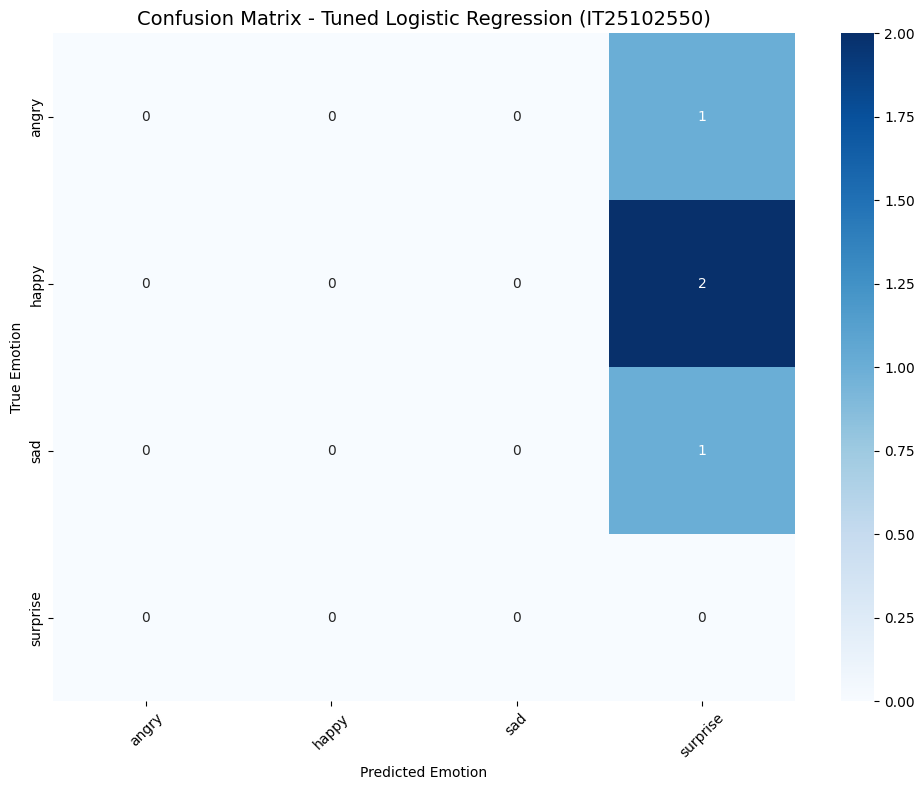

Confusion Matrix saved successfully to 'results/eda_visualizations/member2_logistic_confusion_matrix.png'!


In [12]:
os.makedirs('results/eda_visualizations', exist_ok=True)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)

plt.title('Confusion Matrix - Tuned Logistic Regression (IT25102550)', fontsize=14)
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.xticks(rotation=45)
plt.tight_layout()

save_path = 'results/eda_visualizations/member2_logistic_confusion_matrix.png'
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Confusion Matrix saved successfully to '{save_path}'!")